# 17 - XLM-R large + CharCNN + MLP

Rama contextual XLM-R y rama estilométrica CharCNN en un solo modelo.

In [1]:
# =========================
# Instalación de librerías
# =========================
# Ejecuta esta celda y reinicia el kernel si acabas de instalar paquetes.

%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
%pip install -U transformers accelerate sentencepiece protobuf tokenizers scikit-learn pandas numpy matplotlib tqdm scipy joblib


Found existing installation: torch 2.12.0+cu126
Uninstalling torch-2.12.0+cu126:
  Successfully uninstalled torch-2.12.0+cu126
Found existing installation: torchvision 0.27.0+cu126
Uninstalling torchvision-0.27.0+cu126:
  Successfully uninstalled torchvision-0.27.0+cu126
Found existing installation: torchaudio 2.11.0+cu126
Uninstalling torchaudio-2.11.0+cu126:
  Successfully uninstalled torchaudio-2.11.0+cu126
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download-r2.pytorch.org/whl/cu126/torch-2.12.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchvision-0.27.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchaudio-2.11.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
Using c


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl.metadata (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# =========================
# Imports y configuración base
# =========================

import os
import gc
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("CONFIGURACIÓN DEL ENTORNO")
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memoria GPU GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
print("=" * 80)


CONFIGURACIÓN DEL ENTORNO
PyTorch: 2.12.0+cu126
CUDA disponible: True
Device: cuda
GPU: NVIDIA GeForce RTX 4090
Memoria GPU GB: 23.99


In [3]:
# =========================
# Configuración del problema y carga de datos
# =========================

TRAIN_PATH = "train.csv"
EVAL_PATH = "eval.csv"
TEXT_COL = "text"
LABEL_COL = "decade"

MODEL_NAME = "FacebookAI/xlm-roberta-large"
MAX_LEN = 512
NUM_CLASSES_EXPECTED = 39

EPOCHS = 30
PATIENCE = 2
LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0

LR_TRANSFORMER = 1e-5
LR_HEAD = 2e-4
WEIGHT_DECAY = 1e-4
WARMUP_RATIO = 0.06

BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Carga robusta. Si latin-1 fue la lectura ganadora en tus pruebas, cambia encoding aquí.
df = pd.read_csv(TRAIN_PATH)
df = df[[TEXT_COL, LABEL_COL]].copy()
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

decades = sorted(df[LABEL_COL].unique())
decade_to_idx = {d: i for i, d in enumerate(decades)}
idx_to_decade = {i: d for d, i in decade_to_idx.items()}
df["label_idx"] = df[LABEL_COL].map(decade_to_idx).astype(int)
NUM_CLASSES = len(decades)

print("Shape train.csv:", df.shape)
print("Décadas:", decades[0], "a", decades[-1])
print("Número de clases:", NUM_CLASSES)
print("Chequeo 150 ->", decade_to_idx.get(150), "| 188 ->", decade_to_idx.get(188))
assert NUM_CLASSES == NUM_CLASSES_EXPECTED, "Número inesperado de clases"
assert decade_to_idx.get(150) == 0, "Error en mapeo: 150 no es clase 0"
assert decade_to_idx.get(188) == 38, "Error en mapeo: 188 no es clase 38"

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df["label_idx"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_idx"])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Distribución train extremos:", train_df[LABEL_COL].value_counts().sort_index().loc[[150, 188]].to_dict())


Shape train.csv: (31403, 3)
Décadas: 150 a 188
Número de clases: 39
Chequeo 150 -> 0 | 188 -> 38
Train: (25122, 3) Val: (3140, 3) Test: (3141, 3)
Distribución train extremos: {150: 629, 188: 647}


In [4]:
# =========================
# Tokenizer
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print("Tokenizer cargado:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Vocab size:", tokenizer.vocab_size)


Tokenizer cargado: FacebookAI/xlm-roberta-large
Tokenizer class: XLMRobertaTokenizer
Vocab size: 250002


In [5]:
# =========================
# Dataset y utilidades RoBERTa/XLM-R
# =========================

class TextDataset(Dataset):
    def __init__(self, dataframe, train_mode=False):
        self.texts = dataframe[TEXT_COL].astype(str).tolist()
        self.labels = dataframe["label_idx"].astype(int).tolist() if "label_idx" in dataframe.columns else None
        self.train_mode = train_mode

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors=None)
        item = {
            "input_ids": torch.tensor(encoded["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoded["attention_mask"], dtype=torch.long),
            "text": text,
        }
        if self.labels is not None:
            item["label"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def text_collate_fn(batch):
    out = {
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "texts": [b["text"] for b in batch],
    }
    if "label" in batch[0]:
        out["labels"] = torch.stack([b["label"] for b in batch])
    return out


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)


def make_loaders(train_part, val_part=None, batch_size=BATCH_SIZE):
    train_ds = TextDataset(train_part, train_mode=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, collate_fn=text_collate_fn, pin_memory=(DEVICE.type == "cuda"))
    if val_part is None:
        return train_loader, None
    val_ds = TextDataset(val_part, train_mode=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, collate_fn=text_collate_fn, pin_memory=(DEVICE.type == "cuda"))
    return train_loader, val_loader


def compute_metrics(logits, labels):
    preds = logits.argmax(dim=1).detach().cpu().numpy()
    y = labels.detach().cpu().numpy()
    pred_decades = np.array([idx_to_decade[int(i)] for i in preds])
    true_decades = np.array([idx_to_decade[int(i)] for i in y])
    abs_err = np.abs(pred_decades - true_decades)
    return {
        "acc": float(np.mean(preds == y)),
        "mae": float(abs_err.mean()),
        "acc_pm1": float(np.mean(abs_err <= 1)),
        "acc_pm2": float(np.mean(abs_err <= 2)),
        "preds": preds,
        "labels": y,
    }


def safe_save_model(path, model, epoch, best_val_acc, extra=None):
    payload = {"epoch": epoch, "model_state_dict": model.state_dict(), "best_val_acc": best_val_acc, "extra": extra or {}}
    tmp_path = str(path) + ".tmp"
    try:
        torch.save(payload, tmp_path)
        if os.path.exists(path):
            os.remove(path)
        os.replace(tmp_path, path)
        print("Checkpoint guardado:", path)
        return True
    except Exception as e:
        print("ADVERTENCIA: no se pudo guardar checkpoint:", repr(e))
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass
        return False


In [8]:
# =========================
# CharCNN utilities
# =========================

MAX_CHAR_LEN = 1400
CHAR_EMB_DIM = 128
CNN_CHANNELS = 192
CNN_KERNELS = [3, 5, 7, 9, 11]
CHAR_PROJ_FACTOR = 1

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
char_counter = Counter()
for text in train_df[TEXT_COL].astype(str):
    char_counter.update(text)
chars = [PAD_TOKEN, UNK_TOKEN] + sorted(char_counter.keys())
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
PAD_IDX = char_to_idx[PAD_TOKEN]
UNK_IDX = char_to_idx[UNK_TOKEN]
VOCAB_SIZE = len(char_to_idx)
print("Char vocab size:", VOCAB_SIZE)


def encode_chars(text, max_len=MAX_CHAR_LEN):
    text = str(text)
    ids = [char_to_idx.get(ch, UNK_IDX) for ch in text[:max_len]]
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))
    return ids[:max_len]

class TextCharDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe[TEXT_COL].astype(str).tolist()
        self.labels = dataframe["label_idx"].astype(int).tolist() if "label_idx" in dataframe.columns else None

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors=None)
        item = {
            "input_ids": torch.tensor(encoded["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoded["attention_mask"], dtype=torch.long),
            "char_ids": torch.tensor(encode_chars(text), dtype=torch.long),
            "text": text,
        }
        if self.labels is not None:
            item["label"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def text_char_collate_fn(batch):
    out = {
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "char_ids": torch.stack([b["char_ids"] for b in batch]),
        "texts": [b["text"] for b in batch],
    }
    if "label" in batch[0]:
        out["labels"] = torch.stack([b["label"] for b in batch])
    return out


def make_char_loaders(train_part, val_part=None, batch_size=BATCH_SIZE):
    train_ds = TextCharDataset(train_part)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, collate_fn=text_char_collate_fn, pin_memory=(DEVICE.type == "cuda"))
    if val_part is None:
        return train_loader, None
    val_ds = TextCharDataset(val_part)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, collate_fn=text_char_collate_fn, pin_memory=(DEVICE.type == "cuda"))
    return train_loader, val_loader


Char vocab size: 191


In [9]:
# =========================
# Modelo XLM-R + CharCNN + MLP
# =========================

class CharCNNEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, channels, kernels, out_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(0.25)
        self.convs = nn.ModuleList([nn.Conv1d(emb_dim, channels, k, padding=k // 2) for k in kernels])
        cnn_dim = channels * len(kernels) * 2
        self.proj = nn.Sequential(
            nn.Linear(cnn_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.35),
        )

    def forward(self, char_ids):
        x = self.embedding(char_ids)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        outs = [F.gelu(conv(x)) for conv in self.convs]
        x = torch.cat(outs, dim=1)
        max_pool = x.max(dim=2).values
        avg_pool = x.mean(dim=2)
        return self.proj(torch.cat([max_pool, avg_pool], dim=1))

class XLMRCharCNNClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.hidden_size = h
        self.char_encoder = CharCNNEncoder(VOCAB_SIZE, CHAR_EMB_DIM, CNN_CHANNELS, CNN_KERNELS, h // 2, PAD_IDX)
        combined_dim = h + h // 2
        self.classifier = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 2 * h),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(2 * h, h),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(h, h // 2),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(h // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask, char_ids):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        roberta_vec = mean_pool(outputs.last_hidden_state, attention_mask)
        char_vec = self.char_encoder(char_ids)
        combined = torch.cat([roberta_vec, char_vec], dim=1)
        return self.classifier(combined)


def build_model():
    model = XLMRCharCNNClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)
    try:
        model.encoder.gradient_checkpointing_enable()
        print("Gradient checkpointing activado.")
    except Exception as e:
        print("No se pudo activar gradient checkpointing:", repr(e))
    print("Hidden size encoder:", model.hidden_size)
    print("Parámetros entrenables:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    return model


In [10]:
# =========================
# Entrenamiento y evaluación
# =========================

def make_optimizer_scheduler(model, train_loader, epochs):
    encoder_params = []
    head_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("encoder."):
            encoder_params.append(p)
        else:
            head_params.append(p)
    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": LR_TRANSFORMER, "weight_decay": WEIGHT_DECAY},
        {"params": head_params, "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY},
    ])
    update_steps = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS) * epochs
    warmup_steps = int(update_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, update_steps)
    return optimizer, scheduler

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))


def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    total_n = 0
    all_logits = []
    all_labels = []
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(tqdm(loader, desc="Training", leave=False), start=1):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(input_ids, attention_mask, batch["char_ids"].to(DEVICE, non_blocking=True))
            loss = criterion(logits, labels)
            loss_for_backward = loss / GRAD_ACCUM_STEPS
        scaler.scale(loss_for_backward).backward()
        if step % GRAD_ACCUM_STEPS == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs
        all_logits.append(logits.detach())
        all_labels.append(labels.detach())
    logits_cat = torch.cat(all_logits)
    labels_cat = torch.cat(all_labels)
    metrics = compute_metrics(logits_cat, labels_cat)
    metrics["loss"] = total_loss / total_n
    return metrics

@torch.no_grad()
def evaluate(model, loader, desc="Validation"):
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_logits = []
    all_labels = []
    for batch in tqdm(loader, desc=desc, leave=False):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(input_ids, attention_mask, batch["char_ids"].to(DEVICE, non_blocking=True))
            loss = criterion(logits, labels)
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs
        all_logits.append(logits.detach())
        all_labels.append(labels.detach())
    logits_cat = torch.cat(all_logits)
    labels_cat = torch.cat(all_labels)
    metrics = compute_metrics(logits_cat, labels_cat)
    metrics["loss"] = total_loss / total_n
    return metrics

@torch.no_grad()
def predict_proba(model, dataframe, batch_size=BATCH_SIZE):
    ds = TextCharDataset(dataframe)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, collate_fn=text_char_collate_fn, pin_memory=(DEVICE.type == "cuda"))
    model.eval()
    probs_all = []
    for batch in tqdm(loader, desc="Predicting", leave=False):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(input_ids, attention_mask, batch["char_ids"].to(DEVICE, non_blocking=True))
            probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())
    return np.vstack(probs_all)


In [11]:
# =========================
# Entrenar XLM-R + CharCNN
# =========================

model = build_model()
train_loader, val_loader = make_char_loaders(train_df, val_df, batch_size=BATCH_SIZE)
optimizer, scheduler = make_optimizer_scheduler(model, train_loader, EPOCHS)

best_val_acc = -1.0
best_epoch = 0
no_improve = 0
best_state = None
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_xlmr_charcnn.pt"

for epoch in range(1, EPOCHS + 1):
    print("-" * 80)
    print("Epoch", epoch, "/", EPOCHS)
    train_metrics = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_metrics = evaluate(model, val_loader, desc="Validation")
    print("Train acc:", round(train_metrics["acc"], 4), "Val acc:", round(val_metrics["acc"], 4), "Val MAE:", round(val_metrics["mae"], 3))
    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch
        no_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        safe_save_model(BEST_MODEL_PATH, model, epoch, best_val_acc)
    else:
        no_improve += 1
        print("Sin mejora por", no_improve, "época(s).")
    if no_improve >= PATIENCE:
        print("Early stopping activado.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()
print("Mejor época:", best_epoch)
print("Mejor val acc:", best_val_acc)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 13835.00it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gradient checkpointing activado.
Hidden size encoder: 1024
Parámetros entrenables: 567554407
--------------------------------------------------------------------------------
Epoch 1 / 30


Training:   0%|          | 0/1571 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Train acc: 0.07 Val acc: 0.1207 Val MAE: 5.254
Checkpoint guardado: checkpoints\best_xlmr_charcnn.pt
--------------------------------------------------------------------------------
Epoch 2 / 30


Train acc: 0.148 Val acc: 0.1936 Val MAE: 3.483
Checkpoint guardado: checkpoints\best_xlmr_charcnn.pt
--------------------------------------------------------------------------------
Epoch 3 / 30


...

Train acc: 0.5531 Val acc: 0.3048 Val MAE: 2.563
Checkpoint guardado: checkpoints\best_xlmr_charcnn.pt
--------------------------------------------------------------------------------
Epoch 12 / 30


Train acc: 0.5989 Val acc: 0.3045 Val MAE: 2.639
Sin mejora por 1 época(s).
--------------------------------------------------------------------------------
Epoch 13 / 30


Train acc: 0.6432 Val acc: 0.3096 Val MAE: 2.566
Checkpoint guardado: checkpoints\best_xlmr_charcnn.pt
--------------------------------------------------------------------------------
Epoch 14 / 30


Train acc: 0.6829 Val acc: 0.3032 Val MAE: 2.539
Sin mejora por 1 época(s).
--------------------------------------------------------------------------------
Epoch 15 / 30


Train acc: 0.7241 Val acc: 0.3096 Val MAE: 2.541
Sin mejora por 2 época(s).
Early stopping activado.
Mejor época: 13
Mejor val acc: 0.3095541401273885


In [12]:
# =========================
# Matriz de confusión y submission helpers
# =========================

def show_confusion(y_true_idx, y_pred_idx, title="Matriz de confusión sin normalizar"):
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(NUM_CLASSES)))
    cm_df = pd.DataFrame(cm, index=[idx_to_decade[i] for i in range(NUM_CLASSES)], columns=[idx_to_decade[i] for i in range(NUM_CLASSES)])
    display(cm_df)
    plt.figure(figsize=(15, 12))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xlabel("Década predicha")
    plt.ylabel("Década real")
    plt.xticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)], rotation=90)
    plt.yticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)])
    plt.colorbar(label="Conteo")
    plt.tight_layout()
    plt.show()


def make_submission_from_probs(eval_df, probs, path):
    pred_idx = probs.argmax(axis=1)
    answers = [idx_to_decade[int(i)] for i in pred_idx]
    sub = pd.DataFrame({"id": eval_df["id"].values, "answer": answers})
    sub.to_csv(path, index=False)
    print("Submission guardada:", path)
    print("Shape:", sub.shape)
    print("Distribución predicha:")
    display(sub["answer"].value_counts().sort_index())
    return sub


Test acc: 0.3047
Test MAE: 2.62


,150,151,152,153,154,155,156,157,158,159,...,179,180,181,182,183,184,185,186,187,188
150,68,2,0,3,1,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
151,1,68,0,2,0,3,0,1,0,0,...,1,0,0,0,0,0,0,1,0,0
152,4,8,47,0,3,3,0,1,0,0,...,0,0,3,0,1,1,2,1,0,0
153,1,10,6,40,11,6,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
154,1,7,2,4,47,14,1,1,3,1,...,1,0,0,0,0,0,0,0,0,0
155,0,6,3,1,5,39,0,7,6,7,...,0,0,0,0,0,0,0,1,1,0
156,0,1,3,0,3,9,27,3,6,6,...,0,0,0,1,0,0,0,0,0,0
157,0,0,0,0,0,11,3,19,7,13,...,0,0,0,0,0,1,0,0,0,0
158,0,0,0,1,1,1,0,9,20,17,...,0,1,0,0,0,0,0,0,0,0
159,0,0,0,0,0,1,0,6,7,36,...,0,1,1,0,0,0,0,0,0,0


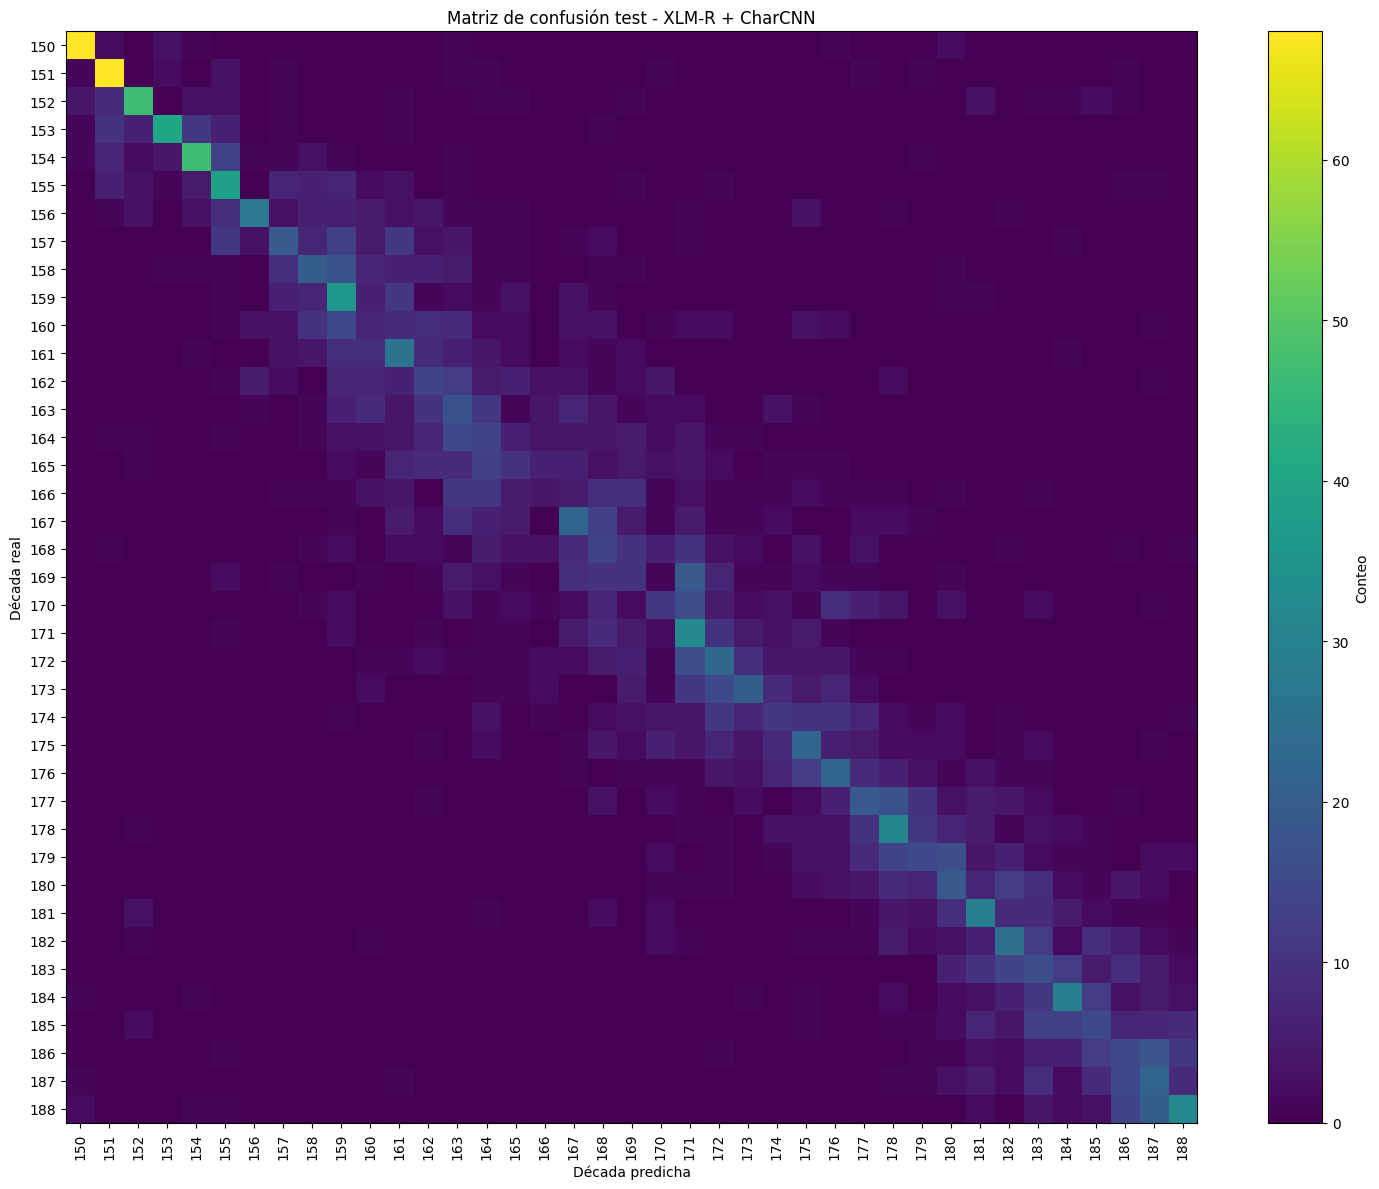

Submission guardada: submission_xlmr_charcnn.csv
Shape: (3490, 2)
Distribución predicha:


answer
150     78
151     96
152    101
153     81
154     79
155     85
156     46
157     68
158     77
159    130
160     96
161    110
162    101
163    122
164     86
165     45
166     27
167    118
168    121
169     64
170     58
171    156
172    114
173     61
174     78
175     94
176     92
177     97
178    106
179     63
180     72
181     77
182    129
183     89
184     80
185     88
186    115
187    106
188     84
Name: count, dtype: int64

In [13]:
# =========================
# Evaluar test y generar submission
# =========================

test_loader = DataLoader(TextCharDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=text_char_collate_fn, pin_memory=(DEVICE.type == "cuda"))
test_metrics = evaluate(model, test_loader, desc="Test")
print("Test acc:", round(test_metrics["acc"], 4))
print("Test MAE:", round(test_metrics["mae"], 3))
show_confusion(test_metrics["labels"], test_metrics["preds"], title="Matriz de confusión test - XLM-R + CharCNN")

eval_df = pd.read_csv(EVAL_PATH)
eval_df[TEXT_COL] = eval_df[TEXT_COL].fillna("").astype(str)
eval_probs = predict_proba(model, eval_df, batch_size=BATCH_SIZE)
submission = make_submission_from_probs(eval_df, eval_probs, "submission_xlmr_charcnn.csv")
